# Workbook 31 — DT-neutron preheat and local $p+{}^{15}$N burn clock

This workbook asks two deliberately narrow questions.

1. At its **initial 14.1-MeV energy**, how far does a DT neutron travel in each Roman fuel recipe before its first collision, a nonelastic reaction, capture, or appreciable energy transfer?
2. If fully burned DT veins are embedded in the Trajan $p+{}^{15}$N driver, what zero-D temperature rise can their neutrons and alphas give nearby driver fuel, and how quickly can that seeded material burn in an optimistic local box?

This is not yet a burn-front simulation. In particular, it does not turn a local reaction time into a demonstrated spatial detonation speed. The final section shows a transparent range/time heuristic and states exactly what is still missing.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
while repo_root.name != 'CNO' and repo_root != repo_root.parent:
    repo_root = repo_root.parent
source_root = repo_root / 'analysis' / 'src'
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from cno_sweep import load_builtin_neutron_cross_sections
from cno_sweep.constants import ATOMIC_MASS
from cno_sweep.n15_pusher import additive_volume_density, mixture_state
from cno_sweep.neutron_heating import (
    dt_vein_matrix_preheat,
    dt_vein_neighbor_preheat,
    fast_neutron_lengths,
    pn15_self_heating_delta_temperature_keV,
    pn15_zero_loss_burn_time_s,
)
from cno_sweep.neutron_transport import Material, number_densities

xs = load_builtin_neutron_cross_sections()
print(xs.metadata)

{'library': 'ENDF/B-VIII.0 neutron reaction sublibrary', 'source_url': 'https://www.nndc.bnl.gov/endf-b8.0/zips/ENDF-B-VIII.0_neutrons.zip', 'archive_md5': '90c1b1a6653a148f17cbf3c5d1171859', 'units': {'energy': 'eV', 'cross_section': 'barn'}}


## Material cards

These are comparison compositions at ideal volume-additive condensed densities. They are **not** final target recipes. The hydrogen-bearing recipes are shown at 1:1 heavy-ion:proton except Trajan, whose current comparison ratio is $p:{}^{15}$N = 4$. Constantine is proton-free $^{13}$C+$\alpha$. Physical lengths scale inversely with density, while the corresponding $\rho R$ values do not.

In [2]:
component_density = {
    'h1': 70.8, 'd': 169.0, 't': 300.0, 'he4': 125.0,
    'c12': 2267.0, 'c13': 2267.0,
    'n14': 808.0, 'n15': 808.0,
    'o16': 1141.0, 'o17': 1141.0,
}

def additive_density(abundances):
    mass = sum(xs.mass_number[k] * v for k, v in abundances.items())
    return 1.0 / sum(
        (xs.mass_number[k] * v / mass) / component_density[k]
        for k, v in abundances.items()
    )

cards = {
    'Trajan p+N15 (4:1)': {'h1': 4.0, 'n15': 1.0},
    'Caesar C12+p': {'c12': 1.0, 'h1': 1.0},
    'Constantine C13+alpha': {'c13': 1.0, 'he4': 1.0},
    'Aurelian O16+p': {'o16': 1.0, 'h1': 1.0},
    'Scipio O17+p': {'o17': 1.0, 'h1': 1.0},
    'Diocletian N14+p': {'n14': 1.0, 'h1': 1.0},
    'DT starter': {'d': 1.0, 't': 1.0},
    'external H blanket': {'h1': 1.0},
}
densities = {name: additive_density(a) for name, a in cards.items()}
# Retain the existing nominal condensed equimolar-DT density.
densities['DT starter'] = 250.0
materials = {
    name: Material(name, number_densities(densities[name], a, xs))
    for name, a in cards.items()
}
pd.DataFrame({
    'composition (number ratio)': {k: str(v) for k, v in cards.items()},
    'assumed density (kg/m3)': densities,
})

,composition (number ratio),assumed density (kg/m3)
Trajan p+N15 (4:1),"{'h1': 4.0, 'n15': 1.0}",253.125664
Caesar C12+p,"{'c12': 1.0, 'h1': 1.0}",669.494577
Constantine C13+alpha,"{'c13': 1.0, 'he4': 1.0}",450.516693
Aurelian O16+p,"{'o16': 1.0, 'h1': 1.0}",603.970270
Scipio O17+p,"{'o17': 1.0, 'h1': 1.0}",620.186983
Diocletian N14+p,"{'n14': 1.0, 'h1': 1.0}",476.931970
DT starter,"{'d': 1.0, 't': 1.0}",250.000000
external H blanket,{'h1': 1.0},70.800000


## 14.1-MeV length scales

The **first-collision mean free path** is $1/\Sigma_t$ and is the cleanest result. The elastic energy length weights each elastic collision by the isotropic-center-of-mass mean fractional energy loss. The optimistic energy length additionally treats all nonelastic removal as if the incident neutron energy were deposited locally. That is an upper deposition bound because the packaged ENDF MF=3 tables do not contain outgoing-particle energy distributions. Capture at 14.1 MeV is rare and its mean path is not the slowing-down/capture distance of a neutron after it has thermalized.

In [3]:
rows = []
length_objects = {}
for name, material in materials.items():
    elastic_only = fast_neutron_lengths(
        material, densities[name], xs, 14.1,
        nonelastic_local_deposition_fraction=0.0,
    )
    optimistic = fast_neutron_lengths(
        material, densities[name], xs, 14.1,
        nonelastic_local_deposition_fraction=1.0,
    )
    length_objects[name] = (elastic_only, optimistic)
    rows.append({
        'material': name,
        'rho_kg_m3': densities[name],
        'first_collision_m': optimistic.total_collision_length_m,
        'nonelastic_reaction_m': optimistic.nonelastic_reaction_length_m,
        '14.1MeV_capture_m': optimistic.capture_length_m,
        'elastic_energy_e_fold_m': elastic_only.elastic_energy_attenuation_length_m,
        'optimistic_energy_e_fold_m': optimistic.bounded_energy_attenuation_length_m,
        'collision_rhoR_kg_m2': optimistic.total_collision_areal_density_kg_m2,
        'optimistic_energy_rhoR_kg_m2': optimistic.bounded_energy_areal_density_kg_m2,
    })
lengths_df = pd.DataFrame(rows).set_index('material')
lengths_df.style.format('{:.5g}')

,rho_kg_m3,first_collision_m,nonelastic_reaction_m,14.1MeV_capture_m,elastic_energy_e_fold_m,optimistic_energy_e_fold_m,collision_rhoR_kg_m2,optimistic_energy_rhoR_kg_m2
material,,,,,,,,
Trajan p+N15 (4:1),253.13,0.28317,1.8023,9841,0.84183,0.57381,71.678,145.25
Caesar C12+p,669.49,0.16093,0.65374,2153.8,0.7025,0.33862,107.74,226.71
Constantine C13+alpha,450.52,0.25258,5.6503,15987,1.2221,1.0048,113.79,452.68
Aurelian O16+p,603.97,0.20535,0.72084,8062.3,1.0477,0.42704,124.03,257.92
Scipio O17+p,620.19,0.20377,0.50066,2023.1,1.1557,0.34933,126.38,216.65
Diocletian N14+p,476.93,0.23174,0.86909,11275,1.13,0.49126,110.52,234.3
DT starter,250,0.18569,1.5342,35064,0.52392,0.39055,46.422,97.637
external H blanket,70.8,0.34338,7934.4,7944,0.68679,0.68674,24.311,48.621


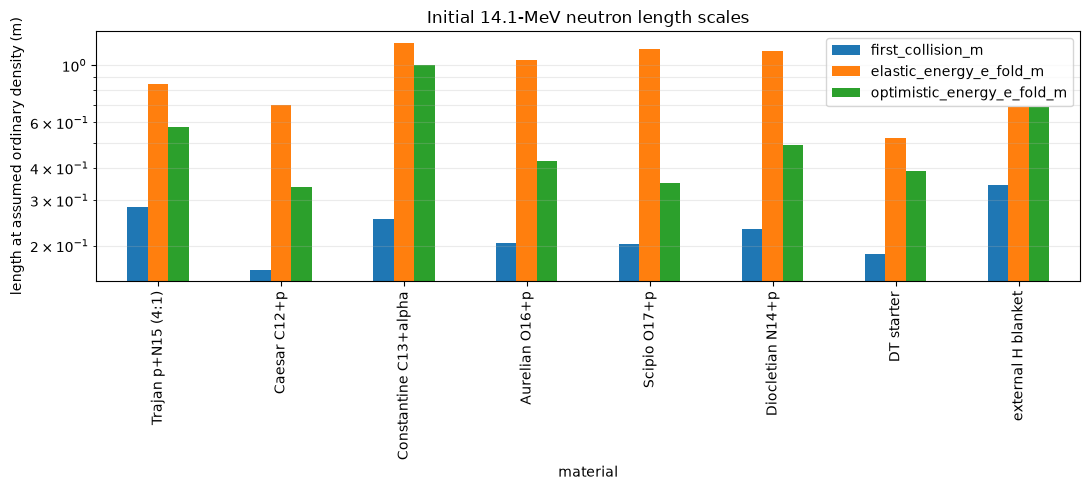

In [4]:
ax = lengths_df[[
    'first_collision_m',
    'elastic_energy_e_fold_m',
    'optimistic_energy_e_fold_m',
]].plot.bar(figsize=(11, 5), logy=True)
ax.set_ylabel('length at assumed ordinary density (m)')
ax.set_title('Initial 14.1-MeV neutron length scales')
ax.grid(axis='y', which='both', alpha=0.25)
plt.tight_layout()

### Density/compression scaling

For a fixed composition, every physical length above is divided by the density multiplier. This does not mean that compression improves neutron escape: $\rho R$ is the invariant. It does mean that DT-vein spacing and depth must be stated at the density that exists when the DT burns.

In [5]:
scale_rows = []
for name in cards:
    base = lengths_df.loc[name]
    for density_multiplier in (1.0, 1.0e3, 1.0e6):
        scale_rows.append({
            'material': name,
            'density_multiplier': density_multiplier,
            'first_collision_m': base.first_collision_m / density_multiplier,
            'optimistic_energy_e_fold_m': base.optimistic_energy_e_fold_m / density_multiplier,
        })
pd.DataFrame(scale_rows).set_index(['material', 'density_multiplier']).style.format('{:.5g}')

## Temperature imparted by fully burned DT veins

This cell converts deposited DT energy into a temperature rise of the neighboring $p:{}^{15}$N=4 matrix. It assumes a homogeneous representative cell, condensed equimolar DT at 250 kg/m³, complete DT burn, and no hydrodynamic work during the deposition interval. The neutron contribution uses $1-e^{-L/\lambda_E}$.

Three brackets are shown: **elastic-only/no alpha sharing**, **optimistic neutron deposition/50% alpha sharing**, and **optimistic neutron deposition/complete alpha sharing**. The last is an energy-conservation ceiling, not a promise that the adjacent nitrogen receives all alpha energy immediately. All temperature rises scale linearly with DT burn fraction.

In [6]:
trajan = mixture_state(4.0, 100.0)
elastic_length, optimistic_length = length_objects['Trajan p+N15 (4:1)']
representative_path_m = optimistic_length.bounded_energy_attenuation_length_m
brackets = {
    'lower: elastic only, alpha=0': (elastic_length.elastic_energy_attenuation_length_m, 0.0),
    'middle: optimistic n, alpha=0.5': (optimistic_length.bounded_energy_attenuation_length_m, 0.5),
    'upper: optimistic n, alpha=1': (optimistic_length.bounded_energy_attenuation_length_m, 1.0),
}
preheat_rows = []
for dt_fraction in (0.001, 0.003, 0.01, 0.03, 0.05, 0.10):
    for bracket, (attenuation_length, alpha_fraction) in brackets.items():
        result = dt_vein_neighbor_preheat(
            dt_volume_fraction=dt_fraction,
            dt_burn_fraction=1.0,
            matrix_path_m=representative_path_m,
            matrix_energy_attenuation_length_m=attenuation_length,
            matrix_n15_density_m3=trajan.nitrogen_density_m3,
            matrix_thermal_particles_per_n15=trajan.thermal_particles_per_n15,
            alpha_to_matrix_fraction=alpha_fraction,
        )
        preheat_rows.append({
            'DT volume fraction': dt_fraction,
            'bracket': bracket,
            'matrix path (m)': representative_path_m,
            'neutron deposited fraction': result.neutron_deposition_fraction,
            'neutron delta kT (keV)': result.neutron_delta_temperature_keV,
            'alpha delta kT (keV)': result.alpha_delta_temperature_keV,
            'total delta kT (keV)': result.total_delta_temperature_keV,
        })
preheat_df = pd.DataFrame(preheat_rows)
preheat_df.set_index(['DT volume fraction', 'bracket']).style.format('{:.5g}')

### The same 1% DT loading beside every fuel

For a common comparison, each row below contains 1% fully burned DT by initial volume and one optimistic initial-energy attenuation length of that particular matrix. Half of the local DT-alpha energy is allowed to reach the matrix. This is a classical, instant-equilibration temperature increment; it is most useful for comparing recipes, not as a final trajectory prediction.

In [7]:
charge = {
    'h1': 1, 'd': 1, 't': 1, 'he4': 2, 'c12': 6, 'c13': 6,
    'n14': 7, 'n15': 7, 'o16': 8, 'o17': 8,
}
all_fuel_preheat_rows = []
for name, abundance in cards.items():
    if name in ('DT starter', 'external H blanket'):
        continue
    formula_mass_amu = sum(xs.mass_number[k] * v for k, v in abundance.items())
    formula_density_m3 = densities[name] / (formula_mass_amu * ATOMIC_MASS)
    ions = sum(abundance.values())
    electrons = sum(charge[k] * v for k, v in abundance.items())
    thermal_particles = ions + electrons
    energy_length = length_objects[name][1].bounded_energy_attenuation_length_m
    result = dt_vein_matrix_preheat(
        dt_volume_fraction=0.01,
        dt_burn_fraction=1.0,
        matrix_path_m=energy_length,
        matrix_energy_attenuation_length_m=energy_length,
        matrix_formula_unit_density_m3=formula_density_m3,
        matrix_thermal_particles_per_formula_unit=thermal_particles,
        alpha_to_matrix_fraction=0.5,
    )
    all_fuel_preheat_rows.append({
        'material': name,
        'thermal particles/formula': thermal_particles,
        'one energy length (m)': energy_length,
        'neutron delta kT (keV)': result.neutron_delta_temperature_keV,
        'half-alpha delta kT (keV)': result.alpha_delta_temperature_keV,
        'total delta kT (keV)': result.total_delta_temperature_keV,
    })
pd.DataFrame(all_fuel_preheat_rows).set_index('material').style.format('{:.5g}')

,thermal particles/formula,one energy length (m),neutron delta kT (keV),half-alpha delta kT (keV),total delta kT (keV)
material,,,,,
Trajan p+N15 (4:1),16,0.57381,14.048,2.7801,16.828
Caesar C12+p,9,0.33862,6.4604,1.2785,7.7389
Constantine C13+alpha,10,1.0048,11.299,2.2361,13.535
Aurelian O16+p,11,0.42704,7.6621,1.5163,9.1784
Scipio O17+p,11,0.34933,7.9007,1.5636,9.4642
Diocletian N14+p,10,0.49126,9.4176,1.8638,11.281


### DT depth is a controllable preheat lever

The next table holds DT loading fixed and changes the amount of Trajan material through which its neutrons travel. Moving a vein farther from a free surface raises neutron deposition; moving it toward the Pb edge lowers deposition in Trajan and sends more neutron energy toward the tamper. This is the first-order reason vein depth matters. A real spherical calculation must include both inward and outward solid angles and the materials on both sides.

In [8]:
depth_rows = []
for dt_fraction in (0.01, 0.05):
    for path_m in (0.05, 0.10, 0.30, representative_path_m, 1.0, 3.0):
        result = dt_vein_neighbor_preheat(
            dt_volume_fraction=dt_fraction,
            dt_burn_fraction=1.0,
            matrix_path_m=path_m,
            matrix_energy_attenuation_length_m=optimistic_length.bounded_energy_attenuation_length_m,
            matrix_n15_density_m3=trajan.nitrogen_density_m3,
            matrix_thermal_particles_per_n15=trajan.thermal_particles_per_n15,
            alpha_to_matrix_fraction=0.5,
        )
        depth_rows.append({
            'DT volume fraction': dt_fraction,
            'one-sided Trajan path (m)': path_m,
            'neutron deposited fraction': result.neutron_deposition_fraction,
            'delta kT (keV)': result.total_delta_temperature_keV,
        })
pd.DataFrame(depth_rows).set_index(['DT volume fraction', 'one-sided Trajan path (m)']).style.format('{:.5g}')

### Effective light-off across an inter-vein cell

A distributed vein network need not wait for a p+N15 flame to cross the whole mantle. A more relevant screening metric is the distance from a burned DT segment to a representative matrix point divided by neutron flight time plus that point's local N15 induction time. The calculation below uses one optimistic initial-energy attenuation length, the middle deposition bracket, complete DT burn, and 10% N15 burn as the light-off criterion.

This is still not a demonstrated wave speed: it assumes the relevant DT segment has already burned, uses a one-sided homogeneous-cell deposition model, and omits expansion and radiation. It does expose the sharp DT-loading threshold and supplies a number that the later vein-network timing model can use honestly.

In [9]:
elementary_charge_c = 1.602176634e-19
neutron_mass_kg = 1.67492749804e-27
neutron_speed_m_s = np.sqrt(
    2.0 * 14.069e6 * elementary_charge_c / neutron_mass_kg
)
flight_time_s = representative_path_m / neutron_speed_m_s
lightoff_rows = []
for dt_fraction in (0.001, 0.003, 0.01, 0.03, 0.05, 0.10):
    preheat = dt_vein_neighbor_preheat(
        dt_volume_fraction=dt_fraction,
        dt_burn_fraction=1.0,
        matrix_path_m=representative_path_m,
        matrix_energy_attenuation_length_m=optimistic_length.bounded_energy_attenuation_length_m,
        matrix_n15_density_m3=trajan.nitrogen_density_m3,
        matrix_thermal_particles_per_n15=trajan.thermal_particles_per_n15,
        alpha_to_matrix_fraction=0.5,
    )
    induction_s = pn15_zero_loss_burn_time_s(
        initial_n15_density_m3=trajan.nitrogen_density_m3,
        proton_ratio=4.0,
        seed_temperature_keV=preheat.total_delta_temperature_keV,
        target_n15_burn_fraction=0.10,
    )
    lightoff_rows.append({
        'DT volume fraction': dt_fraction,
        'seed delta kT (keV)': preheat.total_delta_temperature_keV,
        'neutron flight (s)': flight_time_s,
        'zero-loss t10 induction (s)': induction_s,
        'cell light-off metric (km/s)': representative_path_m / (flight_time_s + induction_s) / 1000.0,
    })
pd.DataFrame(lightoff_rows).set_index('DT volume fraction').style.format('{:.5g}')

,seed delta kT (keV),neutron flight (s),zero-loss t10 induction (s),cell light-off metric (km/s)
DT volume fraction,,,,
0.001000,1.6676,1.106e-08,2.1913e+09,2.6185e-13
0.003000,5.0129,1.106e-08,405.77,1.4141e-06
0.010000,16.828,1.106e-08,0.0022846,0.25116
0.030000,51.524,1.106e-08,2.0463e-06,278.91
0.050000,87.681,1.106e-08,4.2449e-07,1317.4
0.100000,185.1,1.106e-08,9.166e-08,5586.1


## What $p+{}^{15}$N itself contributes

For $p:{}^{15}$N=4 there are 5 ions and 11 electrons per initial nitrogen nucleus, or 16 thermal particles. With a classical common temperature, their thermal energy is $\tfrac32(16)kT=24kT$. Therefore the exact zero-loss temperature increment from burn fraction $f$ and charged-product deposition fraction $\eta_c$ is

$$\Delta(kT)=\frac{f\,\eta_c\,(4.966\,\mathrm{MeV})}{24}=206.9f\eta_c\;\mathrm{keV}. $$

This is a baseline energy statement. It says how much temperature the reaction energy can buy; it does not say how fast the first reactions occur or prove that their charged products heat the next cold zone.

In [10]:
self_heat_rows = []
for burn_fraction in (0.001, 0.01, 0.05, 0.10, 0.30, 0.50, 1.0):
    for deposition_fraction in (0.25, 0.50, 1.0):
        self_heat_rows.append({
            'N15 burn fraction': burn_fraction,
            'charged-product deposition': deposition_fraction,
            'delta kT (keV)': pn15_self_heating_delta_temperature_keV(
                4.0, burn_fraction, deposition_fraction
            ),
        })
pd.DataFrame(self_heat_rows).set_index([
    'N15 burn fraction', 'charged-product deposition'
]).unstack().round(4)

delta kT (keV)                    
charged-product deposition           0.25      0.50      1.00
N15 burn fraction                                            
0.001                              0.0517    0.1035    0.2069
0.010                              0.5173    1.0346    2.0692
0.050                              2.5865    5.1729   10.3458
0.100                              5.1729   10.3458   20.6917
0.300                             15.5188   31.0375   62.0750
0.500                             25.8646   51.7292  103.4583
1.000                             51.7292  103.4583  206.9167

## Optimistic local runaway clock—and only a heuristic speed

The local box below integrates exact proton and nitrogen depletion while closing temperature with the zero-loss self-heating equation above. It neglects expansion, bremsstrahlung, conduction, and heat spent on neighboring cold fuel. Consequently it is an **optimistic induction time**, not a propagating front.

For scale only, the last column divides the NIST-ASTAR cold 3.72-MeV-alpha range in nitrogen (0.02781 kg/m²) by the time to 10% burn. That quotient is a reproducible charged-product range/induction heuristic. It is not yet the wave speed: hot-plasma stopping, the carbon recoil, electron conduction, geometry, and the ignition threshold of the next zone all remain to be solved.

In [11]:
alpha_cold_range_kg_m2 = 0.02781
alpha_cold_length_m = alpha_cold_range_kg_m2 / trajan.density_kg_m3
clock_rows = []
for seed_kT in (5.0, 10.0, 20.0, 40.0, 60.0, 80.0, 100.0, 150.0, 215.0):
    t10 = pn15_zero_loss_burn_time_s(
        initial_n15_density_m3=trajan.nitrogen_density_m3,
        proton_ratio=4.0,
        seed_temperature_keV=seed_kT,
        target_n15_burn_fraction=0.10,
    )
    t50 = pn15_zero_loss_burn_time_s(
        initial_n15_density_m3=trajan.nitrogen_density_m3,
        proton_ratio=4.0,
        seed_temperature_keV=seed_kT,
        target_n15_burn_fraction=0.50,
    )
    t90 = pn15_zero_loss_burn_time_s(
        initial_n15_density_m3=trajan.nitrogen_density_m3,
        proton_ratio=4.0,
        seed_temperature_keV=seed_kT,
        target_n15_burn_fraction=0.90,
    )
    clock_rows.append({
        'seed kT (keV)': seed_kT,
        'zero-loss t10 (s)': t10,
        'zero-loss t50 (s)': t50,
        'zero-loss t90 (s)': t90,
        'cold alpha length (m)': alpha_cold_length_m,
        'range/t10 heuristic (km/s)': alpha_cold_length_m / t10 / 1000.0,
    })
clock_df = pd.DataFrame(clock_rows).set_index('seed kT (keV)')
clock_df.style.format('{:.5g}')

,zero-loss t10 (s),zero-loss t50 (s),zero-loss t90 (s),cold alpha length (m),range/t10 heuristic (km/s)
seed kT (keV),,,,,
5.000000,418.03,418.03,418.03,0.00010987,2.6282e-10
10.000000,0.28476,0.28479,0.2848,0.00010987,3.8582e-07
20.000000,0.00051573,0.00052478,0.00052697,0.00010987,0.00021303
40.000000,5.8651e-06,8.7302e-06,1.0488e-05,0.00010987,0.018732
60.000000,1.2187e-06,2.8033e-06,4.2553e-06,0.00010987,0.090151
80.000000,5.3706e-07,1.5974e-06,2.8155e-06,0.00010987,0.20457
100.000000,3.0714e-07,1.0951e-06,2.1297e-06,0.00010987,0.3577
150.000000,1.3178e-07,5.9739e-07,1.3224e-06,0.00010987,0.83371
215.000000,6.9944e-08,3.4542e-07,8.511e-07,0.00010987,1.5708


## What this answers, and what it does not

* **Definite:** a fully burned DT inventory releases a fixed amount of neutron/alpha energy, the material card fixes its macroscopic cross sections, and the heat capacity converts an assumed deposited fraction to $\Delta kT$. Those calculations are explicit above.
* **Useful design lever:** DT volume fraction, burn fraction, spacing, and depth independently control the preheat. A vein near the Pb edge can deliberately deposit less neutron energy in Trajan; a deeper or denser network deposits more.
* **Definite zero-loss baseline:** at $p:{}^{15}$N=4, 1%, 10%, 50%, and 100% N15 burn can add at most 2.07, 20.69, 103.46, and 206.92 keV respectively.
* **Not yet demonstrated:** an intrinsic $p+{}^{15}$N burn speed. The local clock shows why a DT network is attractive, but a wave speed requires at least a radial hot/cold zone calculation with charged-product stopping and energy transfer.
* **Important omission:** Pb is not in the packaged light-nuclide ENDF subset. Workbook 32 must add isotope-resolved Pb data before neutron heating or loss in the tamper is trusted.

The next physics step is therefore small rather than open-ended: use the DT-derived seed-temperature field as the initial condition of a one-dimensional representative cell between two veins, evolve hot and cold $p+{}^{15}$N zones, and ask whether the midpoint ignites before the cell expands. That produces a defensible maximum vein spacing and effective network propagation rate.